## Example workflow to demonstrate particle flagging and optional outputs
### Eleanor Henson, March 2026

This workbook provides a quick example workflow for tracking multiple variables not included in the original `walk_data`, i.e. any variables besides locations and travel times. This notebook uses the presaved `unstructured_model.txt` dictionary for the hydrodynamic inputs. For more information on generating those inputs, please refer to the `unstructured_grid_anuga.ipynb` notebook.

In this notebook, we are specifically demonstrating a use-case of `dorado` to analyze "potential nutrient transport and removal" - citation hopefully coming soon. Two key factors of nutrient removal in hydrologic systems are the residence times and depths of soluble materials in particular regions. 

For this reason, we are show-casing the optional ability to track `depth` at each particle step along with a binary flag. The `roi_flag` in the particle `walk_data` is == 1 when the particle takes a step within a user-defined roi. In our example of nutrient removal, the roi may be an important indicator of heavily vegetated regions, stimulating removal potential.

### Import dependencies

In [1]:
import numpy as np
import scipy
import matplotlib
%matplotlib inline
from matplotlib import pyplot as plt
import json
import os
import dorado
import dorado.particle_track as pt

#### Load in model outputs
Again, we are using the same hydrodynamic data as `unstructured_grid_anuga.ipynb` - for more information on the functions used to set-up the particle routing with the hydrodynamic data, please refer to that notebook.

[(31, 42)]


(101.0, 1.0)

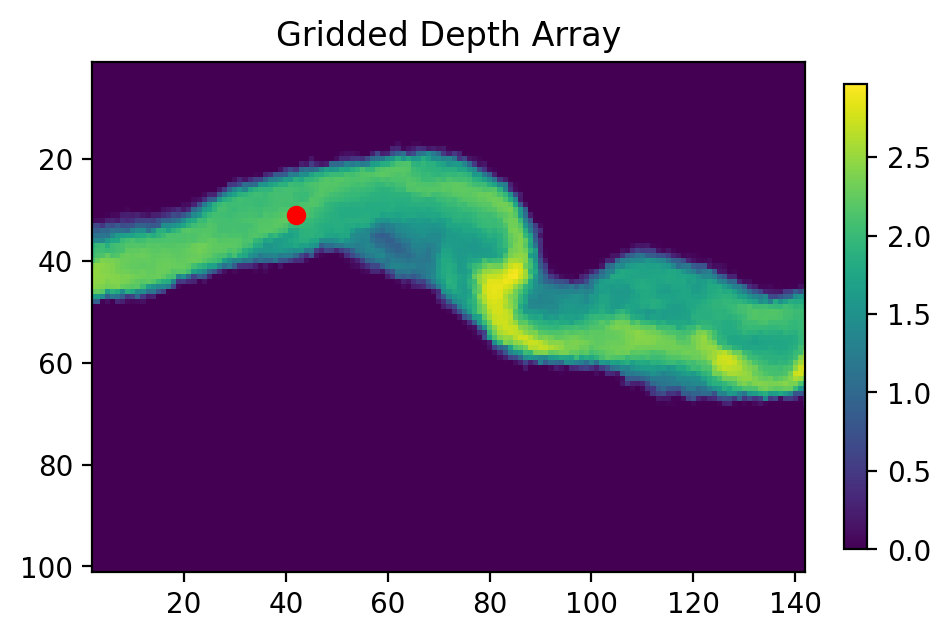

In [2]:
unstructured = json.load(open('unstructured_model.txt'))

# Combine (x,y) coordinates into a list of types for dorado to use
coordinates = [(unstructured['x'][i], unstructured['y'][i]) for i in list(range(len(unstructured['x'])))]

# Run the unstruct2grid function once to acquire the Interp function for all variables
# Use IDW interpolation interpolate unstructured data into uniform grid
myInterp, depth = pt.unstruct2grid(coordinates, unstructured['depth'], 1.0, 3)

# Grid other data products with new interpolation function
stage = myInterp(np.array(unstructured['stage']))
qx = myInterp(np.array(unstructured['qx']))
qy = myInterp(np.array(unstructured['qy']))

# They previously found a nice release location - let's convert it to index notation:
seedloc = [(624464, 3347078)] # Coordinates are in meters UTM

# Call the coordinate transform function
seedind = pt.coord2ind(seedloc, 
                       (min(unstructured['x']), 
                        min(unstructured['y'])), 
                       np.shape(depth), 1.0)
print(seedind)

# Visualize the location on our gridded depth array
plt.figure(figsize=(5,5), dpi=200)
plt.scatter(seedind[0][1], seedind[0][0], c='r')
plt.imshow(depth)
plt.colorbar(fraction=0.03)
plt.title('Gridded Depth Array')
plt.xlim([seedind[0][1]-40, seedind[0][1]+100])
plt.ylim([seedind[0][0]+70, seedind[0][0]-30])


#### Now we are going to use the depth array to define an arbitrary region we think may have enhanced nutrient processing.

Text(0.5, 1.0, 'Gridded Depth Array')

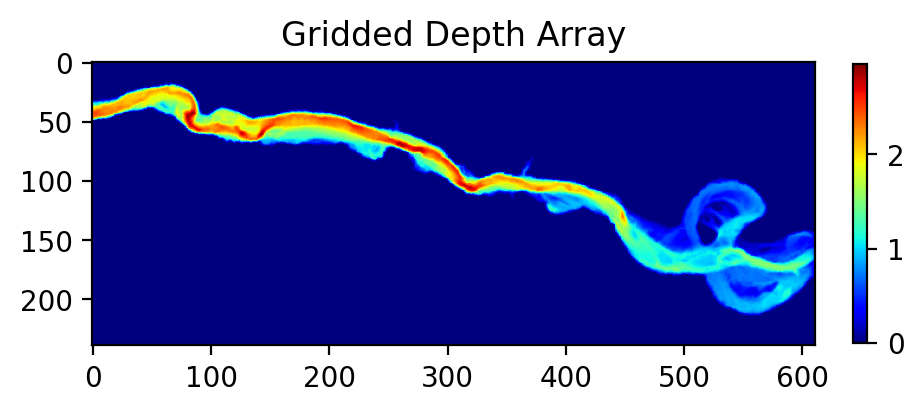

In [3]:
# Let's plot the depth
plt.figure(figsize=(5,5), dpi=200)
plt.imshow(depth, cmap='jet')
plt.colorbar(fraction=0.018)
plt.title('Gridded Depth Array')

Let's theoretically say that any depths between 0.2m and 0.5m are ideal for some form of nutrient processing. Anytime a particle enters that region we want it to be flagged for potential uptake. Here we will make an roi corresponding to this criteria. 

Please note, this is not accurate for nutrient processing. The user should likely delineate the roi using a shapefile or such over the domain. In that case though, the user does have to ensure the shapefile is in the same gridded shape as the model domain.

[0. 1.]


Text(0.5, 1.0, 'Gridded ROI for Flagging')

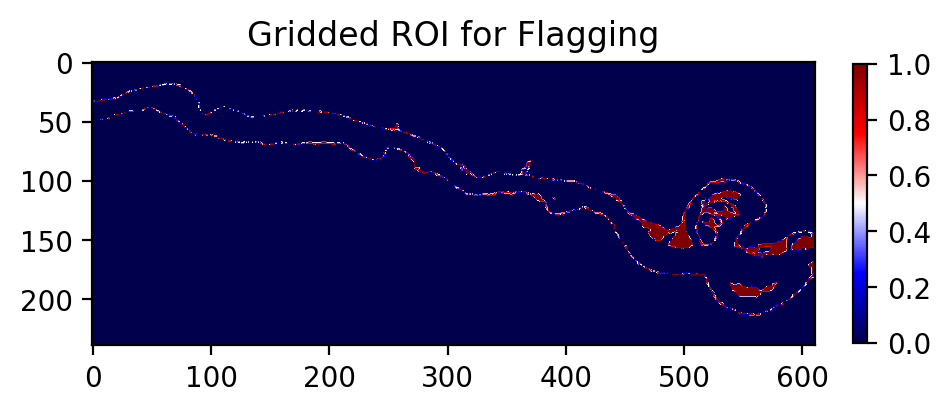

In [4]:
# Let's base the roi on depth
roi_grid = np.zeros_like(depth)
roi_grid[(depth > 0.2) & (depth < 0.5)] = 1

print(np.unique(roi_grid))

# Let's plot the roi
plt.figure(figsize=(5,5), dpi=200)
plt.imshow(roi_grid, cmap='seismic')
plt.colorbar(fraction=0.018)
plt.title('Gridded ROI for Flagging')


#### Set up particle class
We can input any of the hydrodynamic variables dorado uses (`u`, `v`, `qx`, `qy`, `depth`, `stage`) to the `particle_variables` in the `modelParams` class to track along with particle movement. Here we are going to assign the roi we built and track depth, along with the three core variables of `xinds`, `yinds`, and `travel_times`.

Nutrients are assumed to flow with the bulk of water, assuming a `theta` coefficient == 1. We are also using the default `diff_coeff` in this example, but it is encouraged, especially for soluble material transport, to evaluate the sensitivity of that choice on your results.

In [5]:
# Create the parameters object and then assign the values
params = pt.modelParams()

# Populate the params attributes
params.stage = stage
params.depth = depth
params.qx = qx
params.qy = qy

# Other choices/parameters
params.dx = 1. # Grid size
params.dry_depth = 0.01 # 1 cm considered dry
params.theta = 1.0
params.particle_variables =['depth']
params.roi_grid = roi_grid

#### Now time to generate some particles!
Even thought this is a steady flow field, we want to watch how the particles propagate through each step here, as opposed to running the all-inclusive `routines.steady_plots` function. 

In [6]:
# Let's assume we have hydrodynamic results every minute
model_timestep = 60. # units in seconds

# Let's say we want to run all the particles until a certain number of steps 
num_steps = 10
num_particles = 50

# Create a vector of target times
# We want the particles to move until their travel time is close to this target_time iteration
target_times = np.arange(model_timestep, model_timestep*(num_steps+1), model_timestep)

# Now we seed in the region +/- 1 cell of the seed location we computed earlier
# Note that "xloc" and "yloc" are x and y in the particle coordinate system!
seed_xloc = [seedind[0][0]-1, seedind[0][0]+1]
seed_yloc = [seedind[0][1]-1, seedind[0][1]+1]

# Initialize particles!
particles = pt.Particles(params)


Now we will iterate through each model timestep to propagate the particles

In [7]:
# Specify folder to save figures:
path2folder = 'particle_flagging_example'
os.makedirs(path2folder, exist_ok=True)

# initialize walk_data
walk_data = None 

# Iterate through timesteps
for i in list(range(num_steps)): # 0 to 19
    # The main functional difference with an unsteady model is re-instantiating the 
    # particle class with updated params *inside* the particle routing loop

    # Update the flow field by gridding new time-step
    # We don't have additional timesteps, but if we did, we update params here:
    params.depth = myInterp(unstructured['depth'])
    params.stage = myInterp(unstructured['stage'])
    params.qx = myInterp(unstructured['qx'])
    params.qy = myInterp(unstructured['qy'])

    # Update the particle class with *new flow field* that we should be importing for each timestep above
    particle = pt.Particles(params)
    # Generate some particles only at the first timestep, then let them propagate *on what should be a changing flow field*
    if i == 0:
        particle.generate_particles(num_particles, seed_xloc, seed_yloc, 0, 'random', walk_data)
    else:
        particle.generate_particles(0, [], [], previous_walk_data = walk_data)
    
    # Run the random walk for this "model timestep"
    walk_data = particle.run_iteration(target_times[i])

    # Use get_state() to return original and most recent locations - optional data should include the flag and depth
    x0, y0, t0, optional_data0 = dorado.routines.get_state(walk_data, 0) # Starting locations
    xi, yi, ti, optional_datai = dorado.routines.get_state(walk_data) # Most recent locations

    # Convert to numpy array for plotting differences
    xi = np.array(xi)
    yi = np.array(yi)
    fi = np.array(optional_datai['roi_flag'])

    # Separate the two groups for plotting - we want to change the particle color when they enter the roi
    mask_fi0 = fi == 0
    mask_fi1 = fi == 1   

    if i % 2 == 0: # only plot the every other timestep

        fig = plt.figure(dpi=200)
        ax = fig.add_subplot(111)
        # Plot initial locations
        ax.scatter(y0, x0, c='b', s=0.75)
        # Plot particles in blue when not flagged (fi = 0)
        ax.scatter(yi[mask_fi0], xi[mask_fi0], c='blue', s=0.75, label='fi = 0')
        # Plot particles in red when flagged (fi = 1, in ROI)
        ax.scatter(yi[mask_fi1], xi[mask_fi1], c='red', s=0.25, label='fi = 1')
        ax = plt.gca()
        
        # Also plot depth with positions
        im = ax.imshow(particle.depth)
        plt.title('Depth at Time ' + str(target_times[i]))
        cax = fig.add_axes([ax.get_position().x1+0.01,
                            ax.get_position().y0,
                            0.02,
                            ax.get_position().height])
        cbar = plt.colorbar(im, cax=cax)
        cbar.set_label('Water Depth [m]')

        # Save and close
        plt.savefig(path2folder + '/output_by_dt'+str(i)+'.png')
        plt.close()

#### Now in the particle_flagging_example folder, we have the particle locations through time
The particles turn red when they are in our defined shallow-er roi. Let's look at the walk data a little more.

In [8]:
print(f"What keys were tracked in the walk_data?:", walk_data.keys())

# Check across all particles that the flag is binary
all_flag_values = set()
for ii in range(len(walk_data['xinds'])):
    all_flag_values.update(walk_data['roi_flag'][ii])
print(f"All unique roi_flag values across all particles: {all_flag_values}")


What keys were tracked in the walk_data?: dict_keys(['xinds', 'yinds', 'travel_times', 'depth', 'roi_flag'])
All unique roi_flag values across all particles: {0, 1}


#### Now let's answer the question, do particles that entered the roi have increased residence times?

Number of particles ever in ROI: 28
Number of particles never in ROI: 22
Mean final travel time - ROI particles: 600.12 s
Mean final travel time - non-ROI particles: 600.05 s


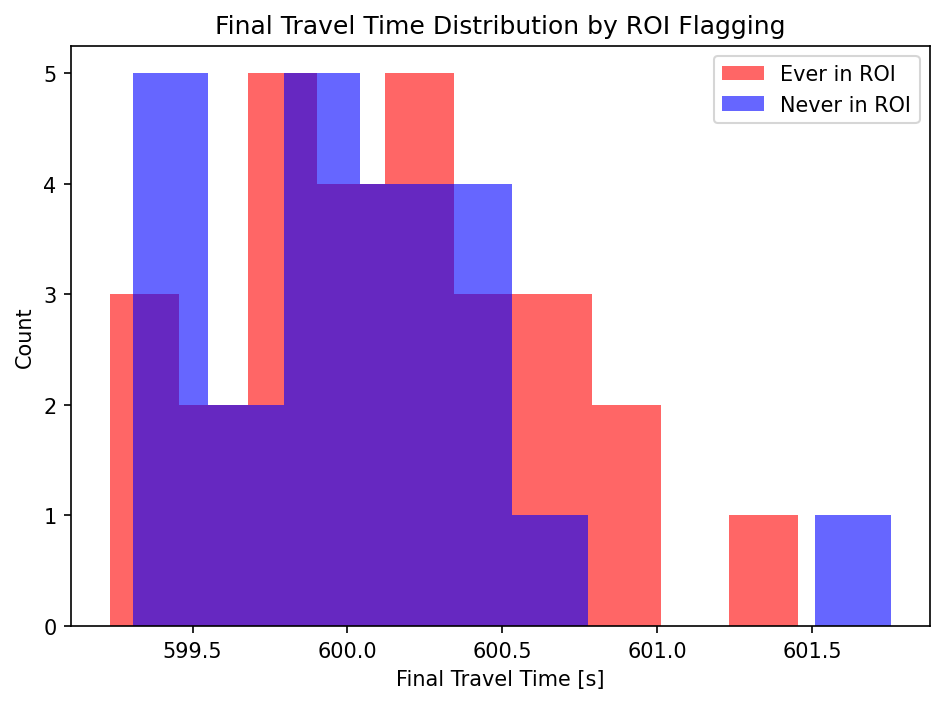

In [9]:
# Here is where we compute the total travel time for each particle
n_particles = len(walk_data['roi_flag'])
roi_time = np.zeros(n_particles)

for p in range(n_particles):
    flags = walk_data['roi_flag'][p]
    times = walk_data['travel_times'][p]

    for i in range(1, len(times)):
        dt = times[i] - times[i - 1]
        curr_flag = flags[i]
        prev_flag = flags[i - 1]

        # Fully in ROI
        if curr_flag == 1 and prev_flag == 1:
            roi_time[p] += dt
        # Transitional step: split in half
        elif curr_flag != prev_flag:
            roi_time[p] += 0.5 * dt
        # else: fully outside ROI (add nothing)

# Separate into ever-flagged vs never-flagged based on roi_time > 0
flagged_travel_times = []
never_flagged_travel_times = []

for ii in range(len(walk_data['xinds'])):
    last_travel_time = walk_data['travel_times'][ii][-1]
    if roi_time[ii] > 0:
        flagged_travel_times.append(last_travel_time)
    else:
        never_flagged_travel_times.append(last_travel_time)

# Summary statistics
print(f"Number of particles ever in ROI: {len(flagged_travel_times)}")
print(f"Number of particles never in ROI: {len(never_flagged_travel_times)}")
if flagged_travel_times:
    print(f"Mean final travel time - ROI particles: {np.mean(flagged_travel_times):.2f} s")
if never_flagged_travel_times:
    print(f"Mean final travel time - non-ROI particles: {np.mean(never_flagged_travel_times):.2f} s")

# Plot distributions
fig, ax = plt.subplots(dpi=150)
ax.hist(flagged_travel_times, alpha=0.6, label='Ever in ROI', color='red')
ax.hist(never_flagged_travel_times, alpha=0.6, label='Never in ROI', color='blue')
ax.set_xlabel('Final Travel Time [s]')
ax.set_ylabel('Count')
ax.set_title('Final Travel Time Distribution by ROI Flagging')
ax.legend()
plt.tight_layout()
plt.show()

#### Welp, doesn't seem to matter here - seems like our ROI was a bit too arbitrary. We hope you can think of some more useful cases for tracking the additional hydrodynamic outputs in the `walk_data` along with the user-defined `roi_grid` than this example provided!